### **Insights from the Review Article: “Building Natural Language Processing Tools for Runyakitara”**

The review article provides an enlightening discussion on efforts to develop Natural Language Processing (NLP) tools for Runyakitara, a group of Bantu languages spoken in western Uganda. It highlights how computational linguistics can play a role in language preservation, education, and technological inclusion for low-resource and endangered languages. A key insight from the paper is the recognition of **language inequality in the digital era**. While languages like English and Kiswahili are well-resourced, indigenous languages such as Runyakitara lack corpora, computational tools, and educational materials. This imbalance not only hinders literacy and digital participation but also accelerates language endangerment. The authors’ initiative to build the *RunyaCorpus* (a collection of written and spoken texts) and *RunyaMorph* (a morphological analyzer) is therefore an essential step toward closing this gap. Another important takeaway is the **integration of NLP with language revitalization and education**. The project envisions tools like *RunyaSpeller* (a spell checker) and *LearnRunya* (a computer-assisted language learning system) to promote accurate writing and facilitate autonomous learning. Such technologies can make Runyakitara accessible to younger generations and urban populations who might otherwise lose touch with their linguistic heritage.The article also exposes the paradox that despite millions of speakers, Runyakitara faces threats due to low social prestige, limited use in formal education, and urbanization trends favoring English. The authors argue that computational tools can enhance the **status and visibility of indigenous languages**, encouraging their use in schools, media, and digital platforms. Finally, the paper demonstrates how **collaboration between computational linguistics and local expertise** can lead to sustainable language development. The partnership between Makerere University and the University of Cambridge exemplifies how global and local efforts can converge to preserve linguistic diversity.

In conclusion, the article underscores that building NLP tools for underrepresented languages is not merely a technical endeavor,it is a cultural and educational mission. The Runyakitara project serves as a model for how technology can empower communities, preserve identity, and ensure linguistic equity in the digital world.



### **Strategic Recommendations for Runyakitara Language Preservation**

1. ***Champion Community-Led Data Curation (The "Runya Corpus")***

The most critical bottleneck for NLP is the "Runya Corpus." Leaders must spearhead efforts to involve the community directly in data collection and digitization. They should also launch a dedicated "Digital Heritage Campaign" to encourage elders, local authors, and schools to contribute existing written texts (folktales, religious texts, local histories) and new speech recordings and acilitate community-wide workshops to train local volunteers on ethical recording, transcription, and digitization standards. Incentivize contributions through small grants, public recognition, or contests.

2. ***Establish a Formal Language Technology Committee***

The project needs institutional permanence that transcends the current academic research team. Formally establish a committee comprising ethnic leaders, local educators, the original academic researchers (as consultants), and local computer science graduates. This committee would govern the project's direction, manage the resources (like the morphological analyser code and corpus data), ensure proper licensing and data sovereignty (control over who can access and use the data), and oversee the long-term maintenance fund.

3. ***Integrate NLP Tools into Primary Education (CALL Systems)***

The primary goal of the NLP effort is revitalization through education. Leaders must ensure the resulting tools are deployed where they can achieve maximum intergenerational impact. They should mandate or strongly advocate for the integration of the Computer-Assisted Language Learning (CALL) systems and the spell-checker (once developed) into the curriculum of all schools in the region.

4. ***Drive Digital Literacy and Tool Adoption***

Promote the NLP applications aggressively through local media, community gatherings, and social media campaigns, focusing on the practical benefits (writing better, learning faster), emphasizing that digital writing in Runyakitara is now easier and more professional due to the tools. Encourage local journalists, content creators, and businesses to use the language in digital formats.

### **Objectives**
**Analyze Sentiment Trends in Financial News**,
examining the distribution of positive, negative, and neutral headlines over time and
Understanding the general tone of financial reporting.

**Detect periods of heightened positive or negative coverage.**

**Identify Key Topics or Keywords** Extract most frequent words or topics from headlines 

**Discover which companies, sectors, or financial events dominate the news**

**How do these Organisation assciate with sentiments** 





In [109]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import feedparser

import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from wordcloud import WordCloud
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.tokenize import word_tokenize
from nltk import pos_tag
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('vader_lexicon')

import warnings
warnings.filterwarnings("ignore")



[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [133]:
# CNBC Finance RSS feed URL
rss_url = "https://www.cnbc.com/id/100003114/device/rss/rss.html"

# Parse the RSS feed
feed = feedparser.parse(rss_url)

# Extract available data from each news item
headlines = [entry.title for entry in feed.entries]
links = [entry.link for entry in feed.entries]
dates = [entry.published for entry in feed.entries]
summaries = [entry.get("summary", "") for entry in feed.entries]

# Create a DataFrame with metadata only
df = pd.DataFrame({
    "Headline": headlines,
    "Link": links,
    "Published": dates,
    "Summary": summaries
})

# Save to CSV file
df.to_csv("cnbc_finance_headlines.csv", index=False)



In [134]:
cnbc_data = pd.read_csv('cnbc_finance_headlines.csv')
cnbc_data

,Headline,Link,Published,Summary
0,Trump administration will set price floors acr...,https://www.cnbc.com/2025/10/15/trump-xi-china...,"Wed, 15 Oct 2025 14:45:55 GMT",China has driven foreign competitors out of bu...
1,Bank of America tops expectations on 43% surge...,https://www.cnbc.com/2025/10/15/bank-of-americ...,"Wed, 15 Oct 2025 12:13:49 GMT","Like its peers, Bank of America's Wall Street ..."
2,"Nvidia, Microsoft, xAI and BlackRock part of $...",https://www.cnbc.com/2025/10/15/nvidia-microso...,"Wed, 15 Oct 2025 14:12:25 GMT","MGX, BlackRock's Global Infrastructure Partner..."
3,"Apple announces new MacBook Pro, iPad Pro and ...",https://www.cnbc.com/2025/10/15/apple-macbook-...,"Wed, 15 Oct 2025 14:51:15 GMT","Apple announced new MacBook Pro, iPad Pro and ..."
4,Morgan Stanley posts massive third-quarter ear...,https://www.cnbc.com/2025/10/15/morgan-stanley...,"Wed, 15 Oct 2025 12:47:20 GMT",Wall Street-centric banks like Morgan Stanley ...
5,Nscale eyes IPO amid fresh $14 billion deal wi...,https://www.cnbc.com/2025/10/15/nscale-eyes-ip...,"Wed, 15 Oct 2025 13:37:41 GMT",The AI cloud company could go public toward th...
6,Honor reveals a new smartphone with a fold-out...,https://www.cnbc.com/2025/10/15/honor-reveals-...,"Wed, 15 Oct 2025 13:08:51 GMT",Chinese smartphone company Honor said it would...
7,A guide to the $1 trillion-worth of AI deals b...,https://www.cnbc.com/2025/10/15/a-guide-to-1-t...,"Wed, 15 Oct 2025 12:41:44 GMT",Artificial intelligence companies are striking...
8,"Alexis Ohanian backs League One Volleyball, fu...",https://www.cnbc.com/2025/10/15/alexis-ohanian...,"Wed, 15 Oct 2025 11:00:01 GMT",Ohanian's investment in volleyball comes as th...
9,Spanish-language audiences are growing even as...,https://www.cnbc.com/2025/10/15/spanish-langua...,"Wed, 15 Oct 2025 13:00:01 GMT",Recent data shows that the Spanish-language au...


In [135]:


# Initialize VADER
sia = SentimentIntensityAnalyzer()

# Function to assign sentiment
def label_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment labeling to the existing 'Headline' column
cnbc_data['Sentiment'] = cnbc_data['Headline'].apply(label_sentiment)

# Show the first 10 rows with new sentiment column
cnbc_data


,Headline,Link,Published,Summary,Sentiment
0,Trump administration will set price floors acr...,https://www.cnbc.com/2025/10/15/trump-xi-china...,"Wed, 15 Oct 2025 14:45:55 GMT",China has driven foreign competitors out of bu...,Negative
1,Bank of America tops expectations on 43% surge...,https://www.cnbc.com/2025/10/15/bank-of-americ...,"Wed, 15 Oct 2025 12:13:49 GMT","Like its peers, Bank of America's Wall Street ...",Positive
2,"Nvidia, Microsoft, xAI and BlackRock part of $...",https://www.cnbc.com/2025/10/15/nvidia-microso...,"Wed, 15 Oct 2025 14:12:25 GMT","MGX, BlackRock's Global Infrastructure Partner...",Neutral
3,"Apple announces new MacBook Pro, iPad Pro and ...",https://www.cnbc.com/2025/10/15/apple-macbook-...,"Wed, 15 Oct 2025 14:51:15 GMT","Apple announced new MacBook Pro, iPad Pro and ...",Positive
4,Morgan Stanley posts massive third-quarter ear...,https://www.cnbc.com/2025/10/15/morgan-stanley...,"Wed, 15 Oct 2025 12:47:20 GMT",Wall Street-centric banks like Morgan Stanley ...,Neutral
5,Nscale eyes IPO amid fresh $14 billion deal wi...,https://www.cnbc.com/2025/10/15/nscale-eyes-ip...,"Wed, 15 Oct 2025 13:37:41 GMT",The AI cloud company could go public toward th...,Positive
6,Honor reveals a new smartphone with a fold-out...,https://www.cnbc.com/2025/10/15/honor-reveals-...,"Wed, 15 Oct 2025 13:08:51 GMT",Chinese smartphone company Honor said it would...,Positive
7,A guide to the $1 trillion-worth of AI deals b...,https://www.cnbc.com/2025/10/15/a-guide-to-1-t...,"Wed, 15 Oct 2025 12:41:44 GMT",Artificial intelligence companies are striking...,Neutral
8,"Alexis Ohanian backs League One Volleyball, fu...",https://www.cnbc.com/2025/10/15/alexis-ohanian...,"Wed, 15 Oct 2025 11:00:01 GMT",Ohanian's investment in volleyball comes as th...,Negative
9,Spanish-language audiences are growing even as...,https://www.cnbc.com/2025/10/15/spanish-langua...,"Wed, 15 Oct 2025 13:00:01 GMT",Recent data shows that the Spanish-language au...,Positive


In [136]:
# Select only the columns you want
cnbc_data2 = cnbc_data[['Headline', 'Sentiment']]

# Show the first few rows
cnbc_data2

,Headline,Sentiment
0,Trump administration will set price floors acr...,Negative
1,Bank of America tops expectations on 43% surge...,Positive
2,"Nvidia, Microsoft, xAI and BlackRock part of $...",Neutral
3,"Apple announces new MacBook Pro, iPad Pro and ...",Positive
4,Morgan Stanley posts massive third-quarter ear...,Neutral
5,Nscale eyes IPO amid fresh $14 billion deal wi...,Positive
6,Honor reveals a new smartphone with a fold-out...,Positive
7,A guide to the $1 trillion-worth of AI deals b...,Neutral
8,"Alexis Ohanian backs League One Volleyball, fu...",Negative
9,Spanish-language audiences are growing even as...,Positive


In [50]:
cnbc_data2.shape

(30, 2)

In [137]:
cnbc_data2.describe()

,Headline,Sentiment
count,30,30
unique,30,3
top,Trump administration will set price floors acr...,Negative
freq,1,10


In [138]:
cnbc_data2['Sentiment'].value_counts()

Sentiment
Negative    10
Positive    10
Neutral     10
Name: count, dtype: int64

In [93]:
cnbc_data2.isna().any()

Headline     False
Sentiment    False
dtype: bool

In [127]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [139]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    tokens = text.split() #form understood by the model

    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words] #Lemmatization helps your sentiment analysis model understand that some words in the data mean the same

    return ' '.join(tokens)

# Apply cleaning
cnbc_data2['cleaned_headline'] = cnbc_data2['Headline'].apply(clean_text)

cnbc_data2


,Headline,Sentiment,cleaned_headline
0,Trump administration will set price floors acr...,Negative,trump administration set price floor across ra...
1,Bank of America tops expectations on 43% surge...,Positive,bank america top expectation surge investment ...
2,"Nvidia, Microsoft, xAI and BlackRock part of $...",Neutral,nvidia microsoft xai blackrock part billion de...
3,"Apple announces new MacBook Pro, iPad Pro and ...",Positive,apple announces new macbook pro ipad pro visio...
4,Morgan Stanley posts massive third-quarter ear...,Neutral,morgan stanley post massive thirdquarter earni...
5,Nscale eyes IPO amid fresh $14 billion deal wi...,Positive,nscale eye ipo amid fresh billion deal microsoft
6,Honor reveals a new smartphone with a fold-out...,Positive,honor reveals new smartphone foldout robotic c...
7,A guide to the $1 trillion-worth of AI deals b...,Neutral,guide trillionworth ai deal openai nvidia others
8,"Alexis Ohanian backs League One Volleyball, fu...",Negative,alexis ohanian back league one volleyball expa...
9,Spanish-language audiences are growing even as...,Positive,spanishlanguage audience growing even tv viewe...


#### Analyze Sentiment Trends in Financial News

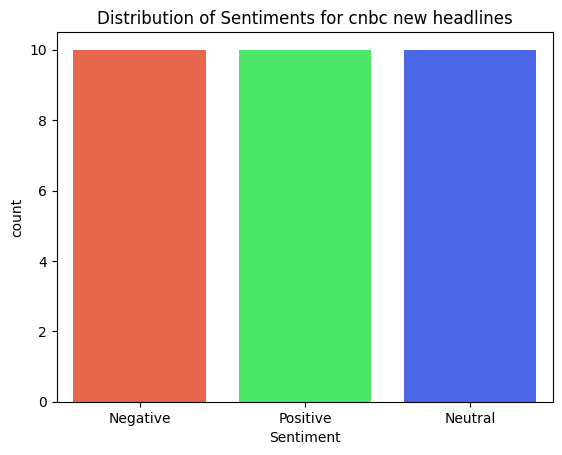

In [180]:
# Plot of sentiment distribution
sns.countplot(x='Sentiment', hue='Sentiment', data=cnbc_data2, palette=['#FF5733', '#33FF57', '#3357FF'], dodge=False, legend=False)
plt.title('Distribution of Sentiments for cnbc new headlines')
plt.show()

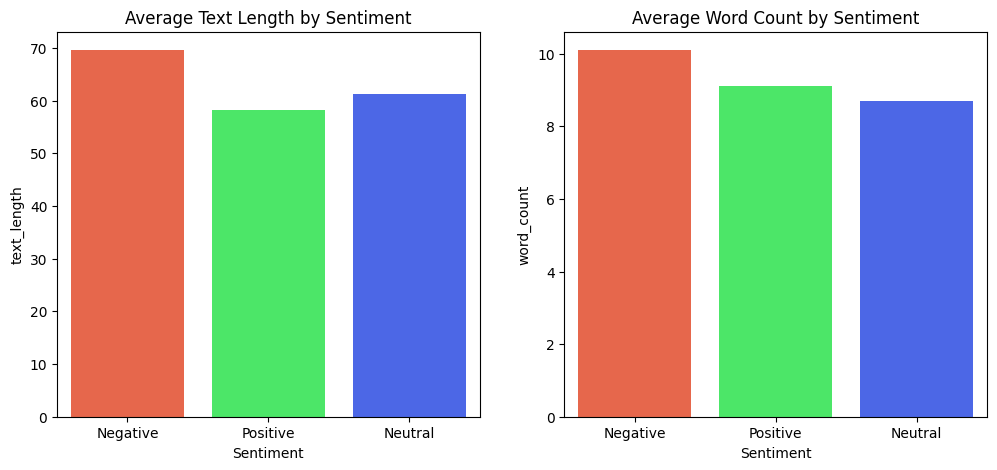

In [140]:
# Text length analysis
cnbc_data2['text_length'] = cnbc_data2 ['cleaned_headline'].apply(len)
cnbc_data2['word_count'] = cnbc_data2['cleaned_headline'].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Average text length by sentiment
plt.subplot(1, 2, 1)
sns.barplot(data=cnbc_data2, x='Sentiment', y='text_length', hue='Sentiment', errorbar=None, dodge=False,palette=['#FF5733', '#33FF57', '#3357FF'],legend=False)
plt.title('Average Text Length by Sentiment')

# Average word count by sentiment
plt.subplot(1, 2, 2)
sns.barplot(data=cnbc_data2, x='Sentiment', y='word_count', hue='Sentiment', errorbar=None, dodge=False, palette=['#FF5733', '#33FF57', '#3357FF'], legend=False)
plt.title('Average Word Count by Sentiment')

plt.show()


 #### Extract most frequent words or topics from headlines

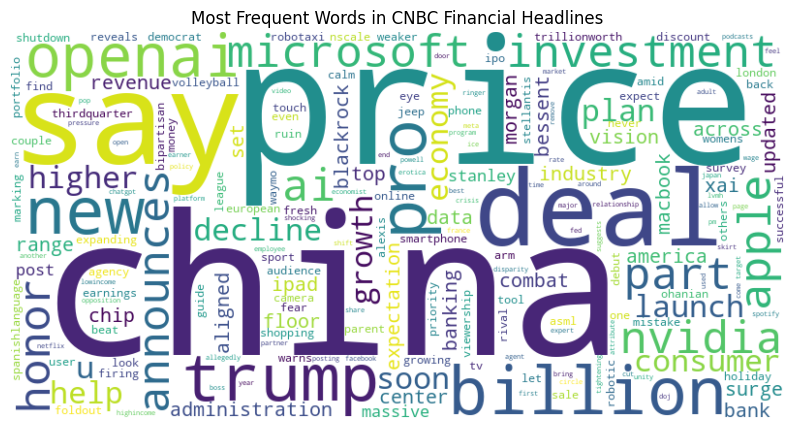

          Word  Frequency
0        china          5
1        price          4
2          say          4
3         deal          4
4        trump          3
5      billion          3
6          new          3
7          pro          3
8   investment          2
9       nvidia          2
10   microsoft          2
11        part          2
12       apple          2
13   announces          2
14       honor          2
15          ai          2
16     decline          2
17           u          2
18        plan          2
19    consumer          2


In [143]:
from collections import Counter
from wordcloud import WordCloud

# Combine all cleaned headlines
all_words = " ".join(cnbc_data2['cleaned_headline'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure(figsize=(10,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in CNBC Financial Headlines')
plt.show()

# Optional: Top 20 words as a table
word_freq = Counter(all_words.split())
top_words = pd.DataFrame(word_freq.most_common(20), columns=['Word', 'Frequency'])
print(top_words)


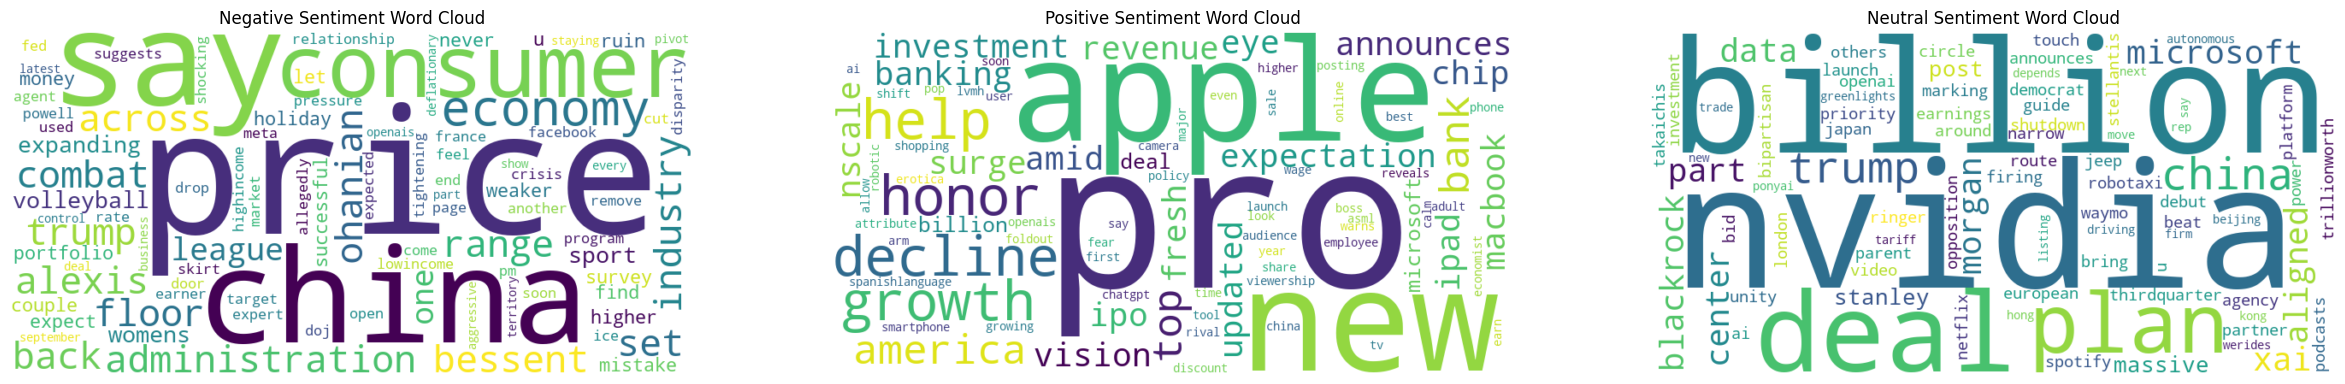

In [ ]:
#Frequent word analysis for each sentiment

from collections import Counter
from wordcloud import WordCloud

sentiments = cnbc_data2['Sentiment'].unique()

fig, axes = plt.subplots(1, 3, figsize=(30, 30))
for i, sentiment in enumerate(sentiments):
    text = ' '.join(cnbc_data2[cnbc_data2['Sentiment'] == sentiment]['cleaned_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{sentiment} Sentiment Word Cloud')
    axes[i].axis('off')
plt.show()

#### Discover which companies, sectors, or financial events dominate the news

In [162]:
import spacy
nlp = spacy.load("en_core_web_sm")


In [ ]:
# Create a function to extract named entities of type ORG (organization/company)
def extract_entities(text):
    doc = nlp(text)
    entities = [ent.text for ent in doc.ents if ent.label_ in ['ORG', 'EVENT', 'GPE', 'PRODUCT']]
    return entities

# Apply to all headlines
cnbc_data2['Entities'] = cnbc_data2['Headline'].apply(extract_entities)



In [165]:
from collections import Counter

all_entities = [entity for sublist in cnbc_data2['Entities'] for entity in sublist]
entity_freq = Counter(all_entities)

# Top 20 entities
top_entities = pd.DataFrame(entity_freq.most_common(20), columns=['Entity', 'Frequency'])
print(top_entities)


                     Entity  Frequency
0                     China          5
1                    OpenAI          3
2                    Nvidia          2
3                 Microsoft          2
4                     Apple          2
5                      U.S.          2
6                   Bessent          1
7           Bank of America          1
8                 BlackRock          1
9      Aligned Data Centers          1
10              MacBook Pro          1
11  iPad Pro and Vision Pro          1
12           Morgan Stanley          1
13                      IPO          1
14                       AI          1
15    League One Volleyball          1
16                     Jeep          1
17               Stellantis          1
18                   London          1
19                   France          1


#### How do these Organisation assciate with sentiments

In [171]:
positive_entities = [e for sublist in cnbc_data2[cnbc_data2['Sentiment']=='Positive']['Entities'] for e in sublist]
negative_entities = [e for sublist in cnbc_data2[cnbc_data2['Sentiment']=='Negative']['Entities'] for e in sublist]
neutral_entities  = [e for sublist in cnbc_data2[cnbc_data2['Sentiment']=='Neutral']['Entities'] for e in sublist]

positive_freq = Counter(positive_entities)
negative_freq = Counter(negative_entities)
neutral_freq  = Counter(neutral_entities)

# Convert counters to DataFrames
df_pos = pd.DataFrame(positive_freq.items(), columns=['Entity', 'Positive'])
df_neg = pd.DataFrame(negative_freq.items(), columns=['Entity', 'Negative'])
df_neu = pd.DataFrame(neutral_freq.items(), columns=['Entity', 'Neutral'])

# Merge all three on 'Entity'
df_all = pd.merge(df_pos, df_neg, on='Entity', how='outer')
df_all = pd.merge(df_all, df_neu, on='Entity', how='outer')

# Fill NaN with 0 (entities not present in some sentiment)
df_all = df_all.fillna(0).astype({'Positive': int, 'Negative': int, 'Neutral': int})

# Sort by total frequency (optional)
df_all['Total'] = df_all['Positive'] + df_all['Negative'] + df_all['Neutral']
df_all = df_all.sort_values(by='Total', ascending=False).drop(columns='Total').reset_index(drop=True)

# Display
print(df_all.head(20))

                  Entity  Positive  Negative  Neutral
0                  China         1         2        2
1                 OpenAI         1         1        1
2              Microsoft         1         0        1
3                   U.S.         0         1        1
4                 Nvidia         0         0        2
5                  Apple         2         0        0
6                Bessent         0         1        0
7              BlackRock         0         0        1
8                    Fed         0         1        0
9                 France         0         1        0
10  Aligned Data Centers         0         0        1
11       Bank of America         1         0        0
12               Beijing         0         0        1
13                    AI         0         0        1
14                  Jeep         0         0        1
15                 Japan         0         0        1
16                   IPO         1         0        0
17             Hong Kong    

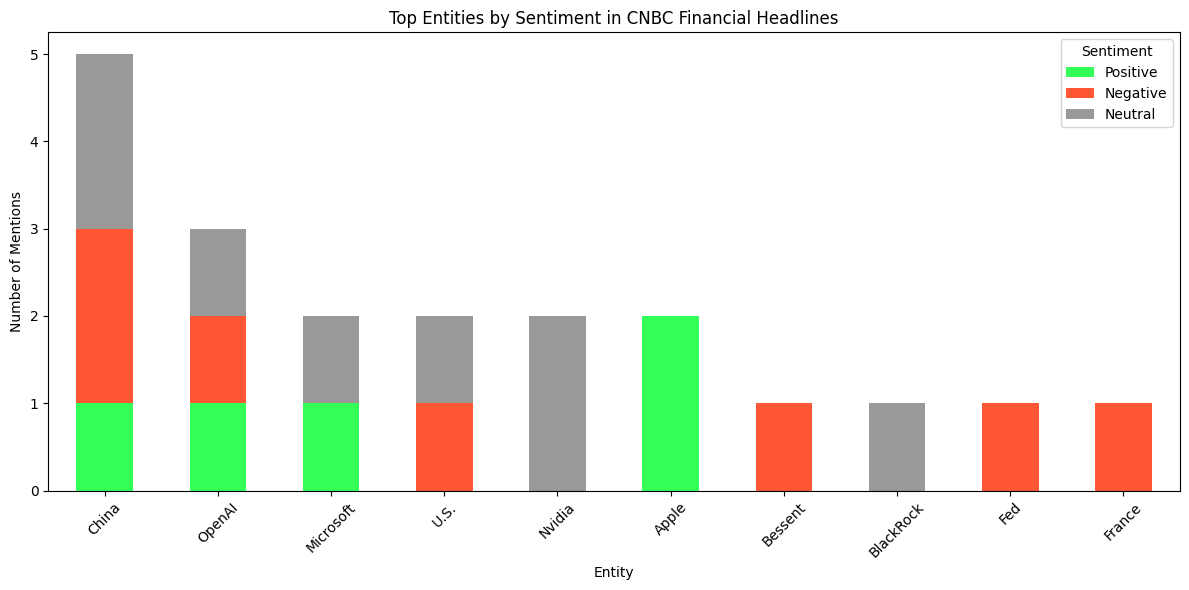

In [178]:
import matplotlib.pyplot as plt

# Select top N entities to avoid clutter
top_n = 10
df_plot = df_all.head(top_n)
df_plot = df_plot.set_index('Entity')

# Plot stacked bar chart
df_plot.plot(kind='bar', 
             stacked=True, 
             figsize=(12,6),
             color=['#33FF57', '#FF5733', '#999999'])

plt.title('Top Entities by Sentiment in CNBC Financial Headlines')
plt.xlabel('Entity')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()


#### Detect periods of heightened positive or negative coverage

2025-10-15 18:19:50,379 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:19:50,380 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:19:50,382 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:19:50,385 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-10-15 18:19:50,

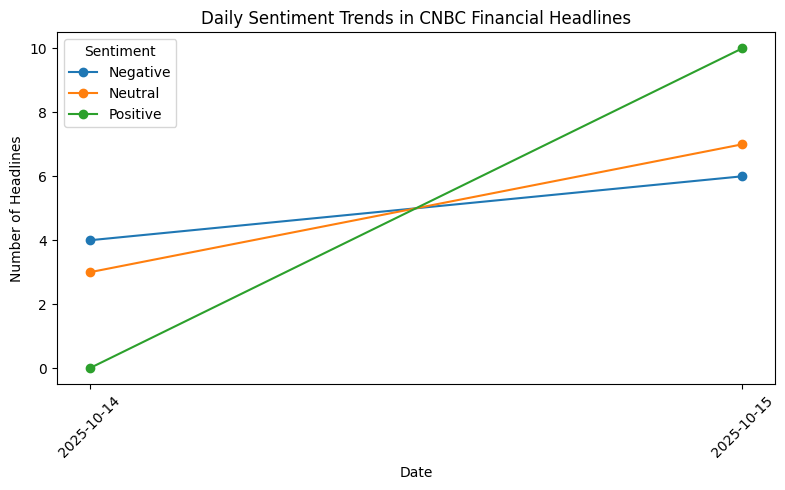

In [ ]:

# Convert 'Published' to datetime
cnbc_data['Published'] = pd.to_datetime(cnbc_data['Published'], errors='coerce', utc=True)

# Create a new column with just the date (no time)
cnbc_data['Date'] = cnbc_data['Published'].dt.date
cnbc_data['Date'] = cnbc_data['Published'].dt.normalize()
cnbc_data['Date'] = cnbc_data['Published'].dt.strftime('%Y-%m-%d')

# Aggregate average sentiment counts by day
sentiment_trends = df.groupby([cnbc_data['Published'].dt.date, cnbc_data['Sentiment']]).size().unstack(fill_value=0)
sentiment_trends_reset = sentiment_trends.reset_index()

# Plot each sentiment as a line
plt.figure(figsize=(8,5))
for col in sentiment_trends.columns:
    plt.plot(sentiment_trends_reset['Date'], sentiment_trends_reset[col], marker='o', label=col)

plt.title('Daily Sentiment Trends in CNBC Financial Headlines')
plt.xlabel('Date')
plt.ylabel('Number of Headlines')
plt.xticks(rotation=45)  # show both dates clearly
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()



#### Sentiment Clasification

In [116]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split

# Prepare features and labels
X = cnbc_data2['cleaned_text']
y = cnbc_data2['Sentiment']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

#### Model Evalution

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Multinomial NB': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Train and evaluate models
results = {}

for name, model in models.items():
    print(f"Training {name}...")

    # Use TF-IDF features
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'predictions': y_pred
    }

    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Training Logistic Regression...
Logistic Regression Accuracy: 0.3333
              precision    recall  f1-score   support

    Negative       1.00      0.50      0.67         2
     Neutral       0.33      0.50      0.40         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.44      0.33      0.36         6
weighted avg       0.44      0.33      0.36         6

--------------------------------------------------
Training Multinomial NB...
Multinomial NB Accuracy: 0.3333
              precision    recall  f1-score   support

    Negative       0.50      0.50      0.50         2
     Neutral       0.25      0.50      0.33         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.33         6
   macro avg       0.25      0.33      0.28         6
weighted avg       0.25      0.33      0.28         6

--------------------------------------------------
Training

In [ ]:
# Creating a DataFrame showing only model names and their accuracy
accuracy_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [results[model]['accuracy'] for model in results]
})

# sort by accuracy descending
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Displaying the DataFrame
accuracy_df


,Model,Accuracy
0,SVM,0.500000
1,Logistic Regression,0.333333
2,Multinomial NB,0.333333
3,Random Forest,0.333333
